# 🏠 Dự đoán giá nhà - Ames Housing Dataset
### Pipeline: EDA → Feature Selection → Preprocessing → Model Training (sklearn)

In [1]:
# 1. Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Feature Selection
from sklearn.feature_selection import SelectKBest, mutual_info_regression, f_regression, RFE
from sklearn.preprocessing import OrdinalEncoder

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


In [2]:
# 2. Đọc dữ liệu
df = pd.read_csv('./data/homedata.csv')
print(f'Shape: {df.shape}')
print(f'\n5 dòng đầu tiên:')
df.head()

Shape: (1460, 81)

5 dòng đầu tiên:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# 3. Thông tin tổng quan
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
# 4. Thống kê mô tả các cột số
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
# 5. Kiểm tra missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

,Missing,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


## 📊 EDA - Exploratory Data Analysis với Seaborn

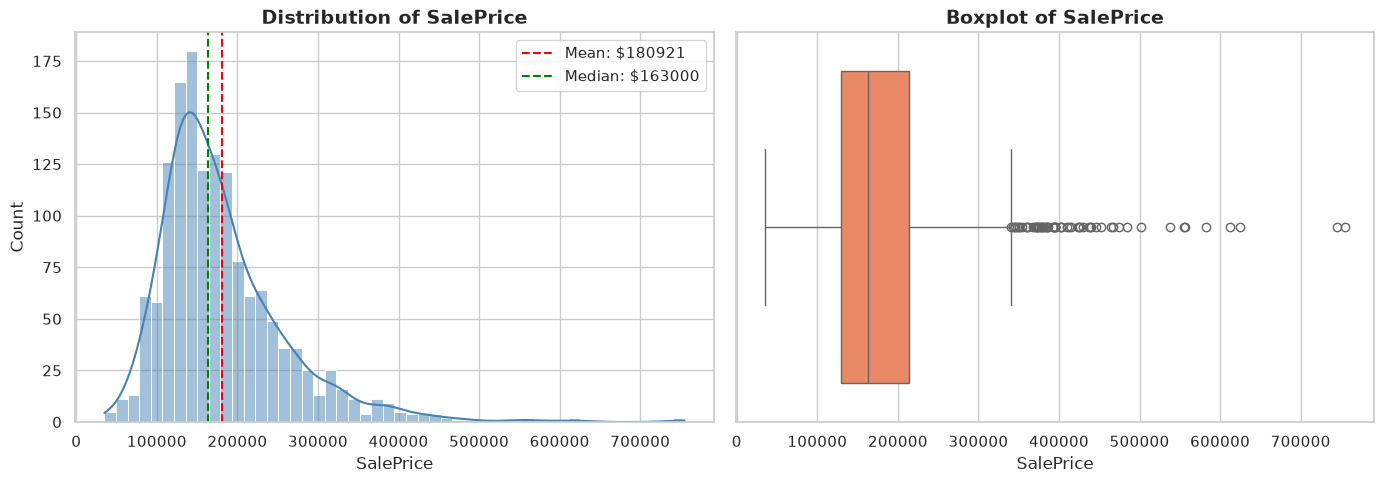

Skewness: 1.88
Kurtosis: 6.54


In [6]:
# 6. Phân phối SalePrice (biến mục tiêu)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of SalePrice', fontsize=14, fontweight='bold')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["SalePrice"].mean():.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--', label=f'Median: ${df["SalePrice"].median():.0f}')
axes[0].legend()

sns.boxplot(x=df['SalePrice'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot of SalePrice', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Skewness: {df["SalePrice"].skew():.2f}')
print(f'Kurtosis: {df["SalePrice"].kurtosis():.2f}')

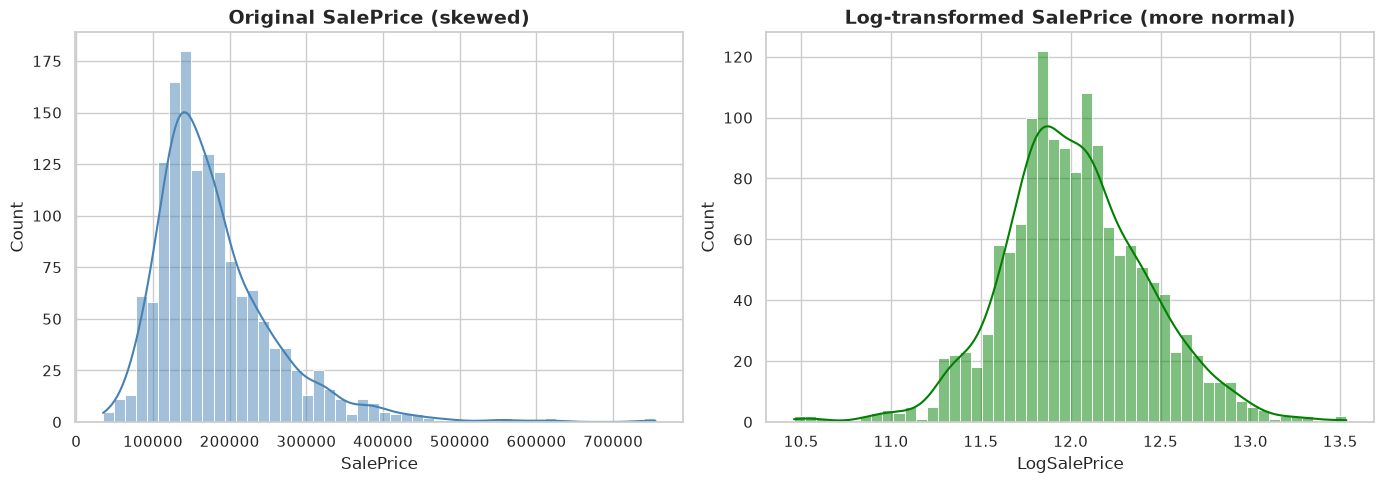

Skewness after log: 0.12


In [7]:
# 7. Log-transform SalePrice (sửa phân phối lệch)
df['LogSalePrice'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Original SalePrice (skewed)', fontsize=14, fontweight='bold')

sns.histplot(df['LogSalePrice'], kde=True, bins=50, ax=axes[1], color='green')
axes[1].set_title('Log-transformed SalePrice (more normal)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Skewness after log: {df["LogSalePrice"].skew():.2f}')

Top 15 features tương quan mạnh nhất với SalePrice:
SalePrice       1.000000
LogSalePrice    0.948374
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


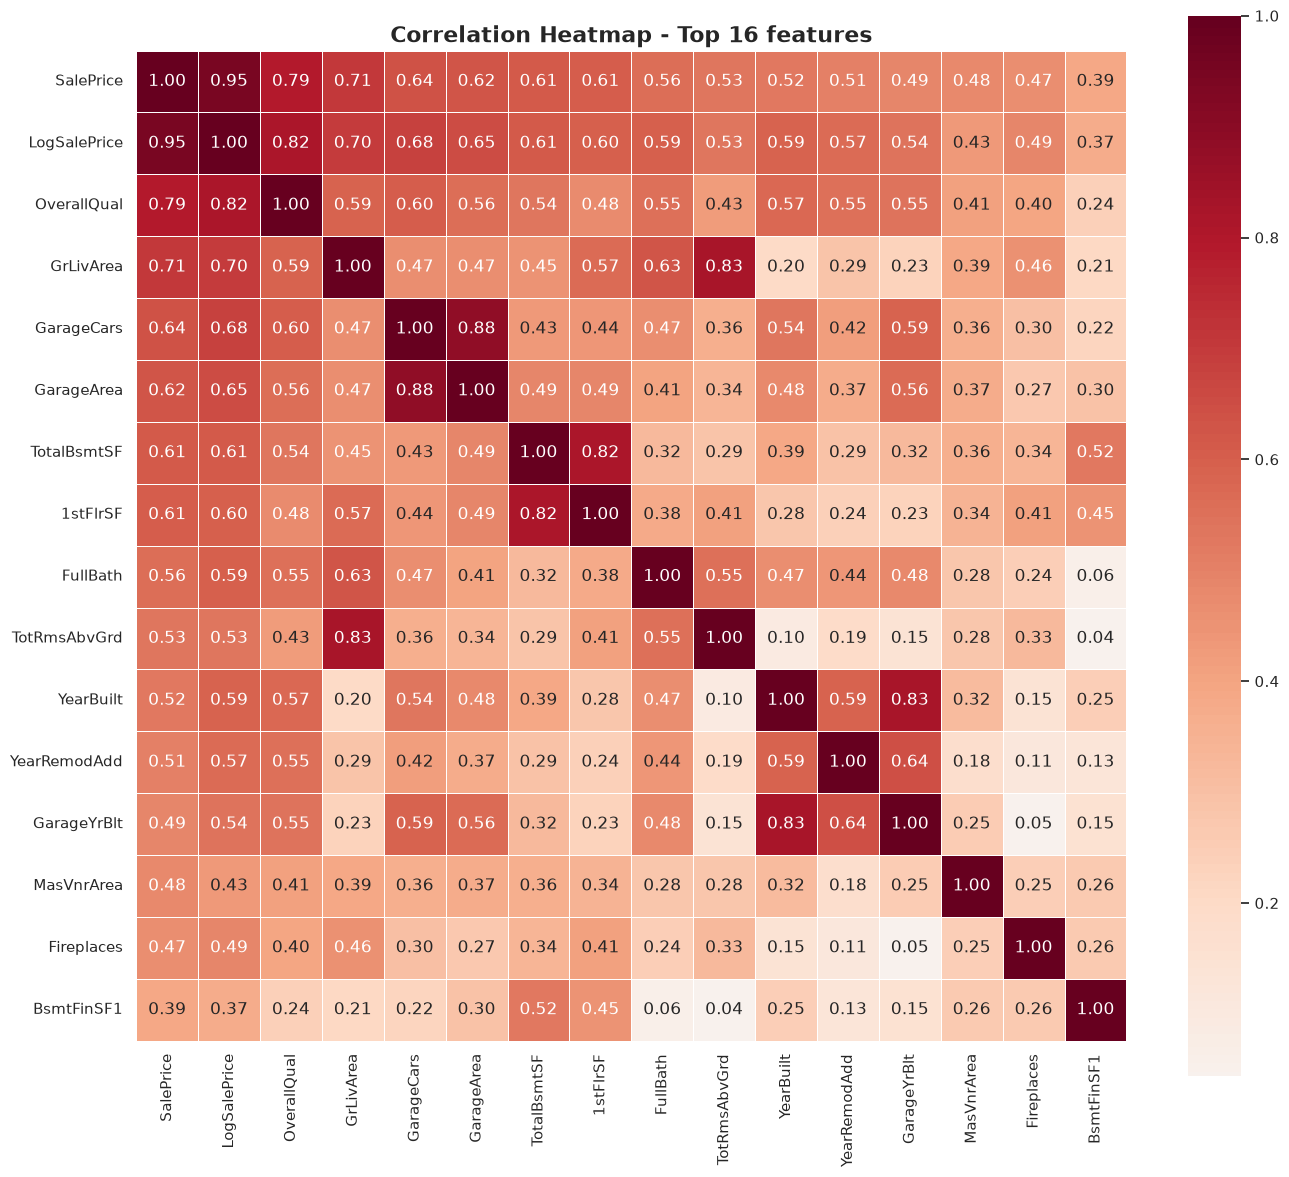

In [8]:
# 8. Correlation Heatmap - các feature số tương quan với SalePrice
# Chọn các cột số
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Id')  # bỏ Id vô dụng

# Tính correlation
corr_matrix = df[numeric_cols].corr()

# Lấy top 15 feature tương quan mạnh nhất với SalePrice
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(16)
print('Top 15 features tương quan mạnh nhất với SalePrice:')
print(top_corr)

# Heatmap cho top features
plt.figure(figsize=(14, 12))
top_features = top_corr.index.tolist()
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap - Top 16 features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

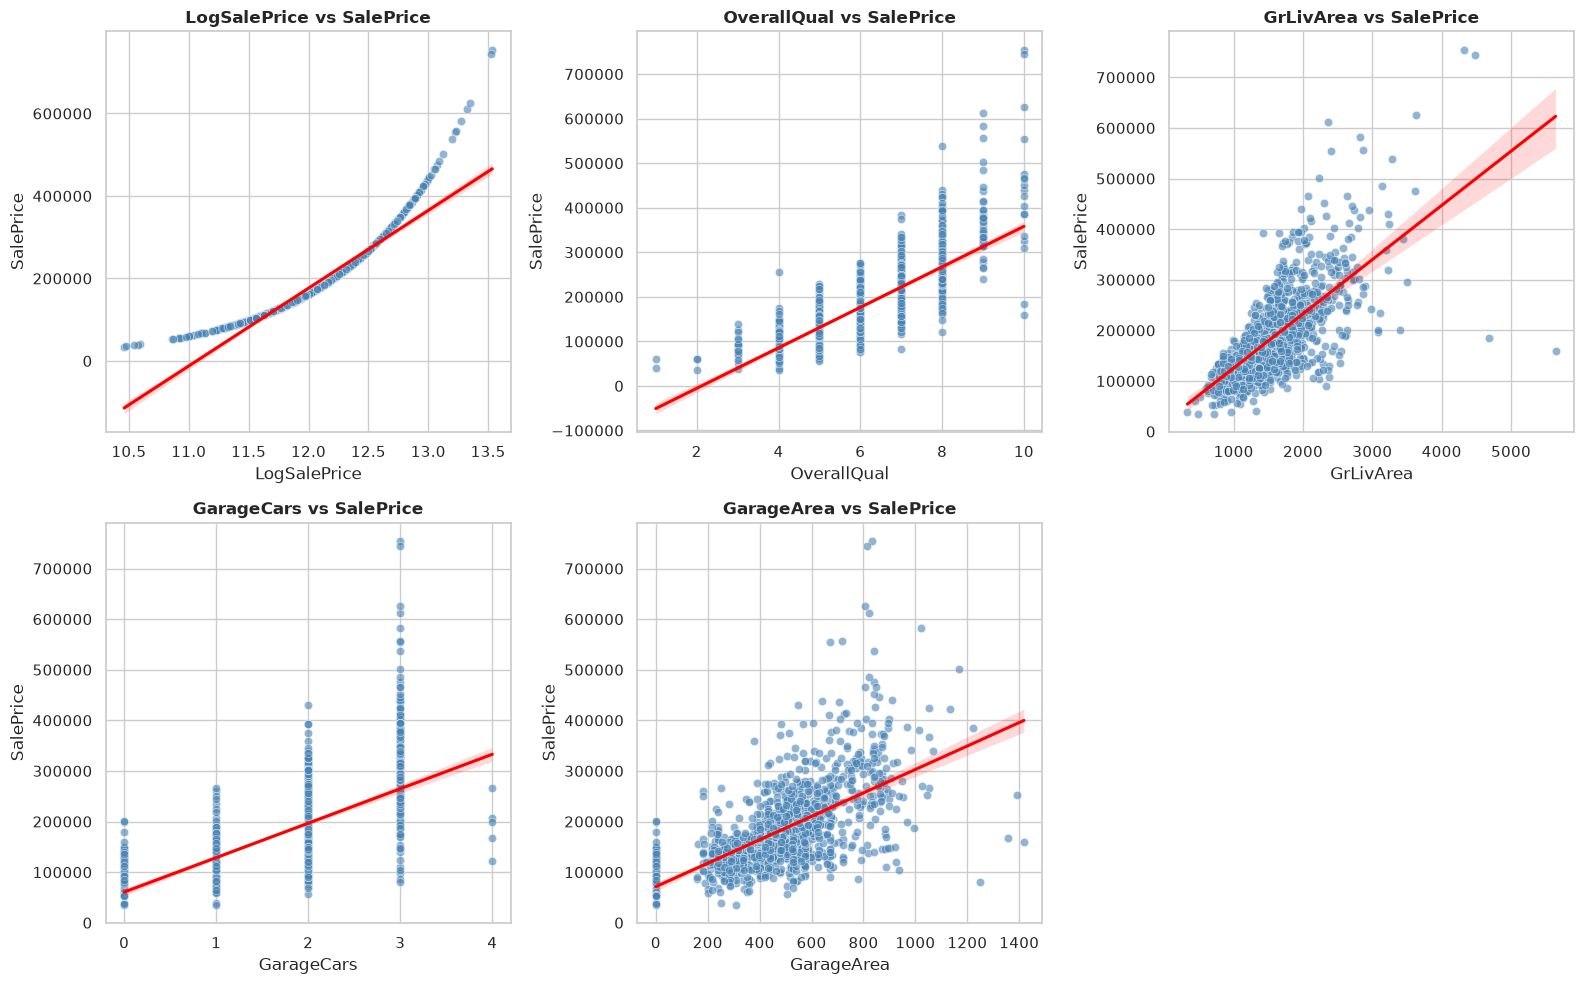

In [9]:
# 9. Scatter plots: Top features vs SalePrice
top_5_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).index[1:6]  # bỏ SalePrice

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(top_5_features):
    sns.scatterplot(data=df, x=feature, y='SalePrice', alpha=0.6, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{feature} vs SalePrice', fontsize=12, fontweight='bold')
    
    # Thêm đường regression line
    sns.regplot(data=df, x=feature, y='SalePrice', scatter=False, ax=axes[i], color='red')

# Ẩn subplot thừa
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

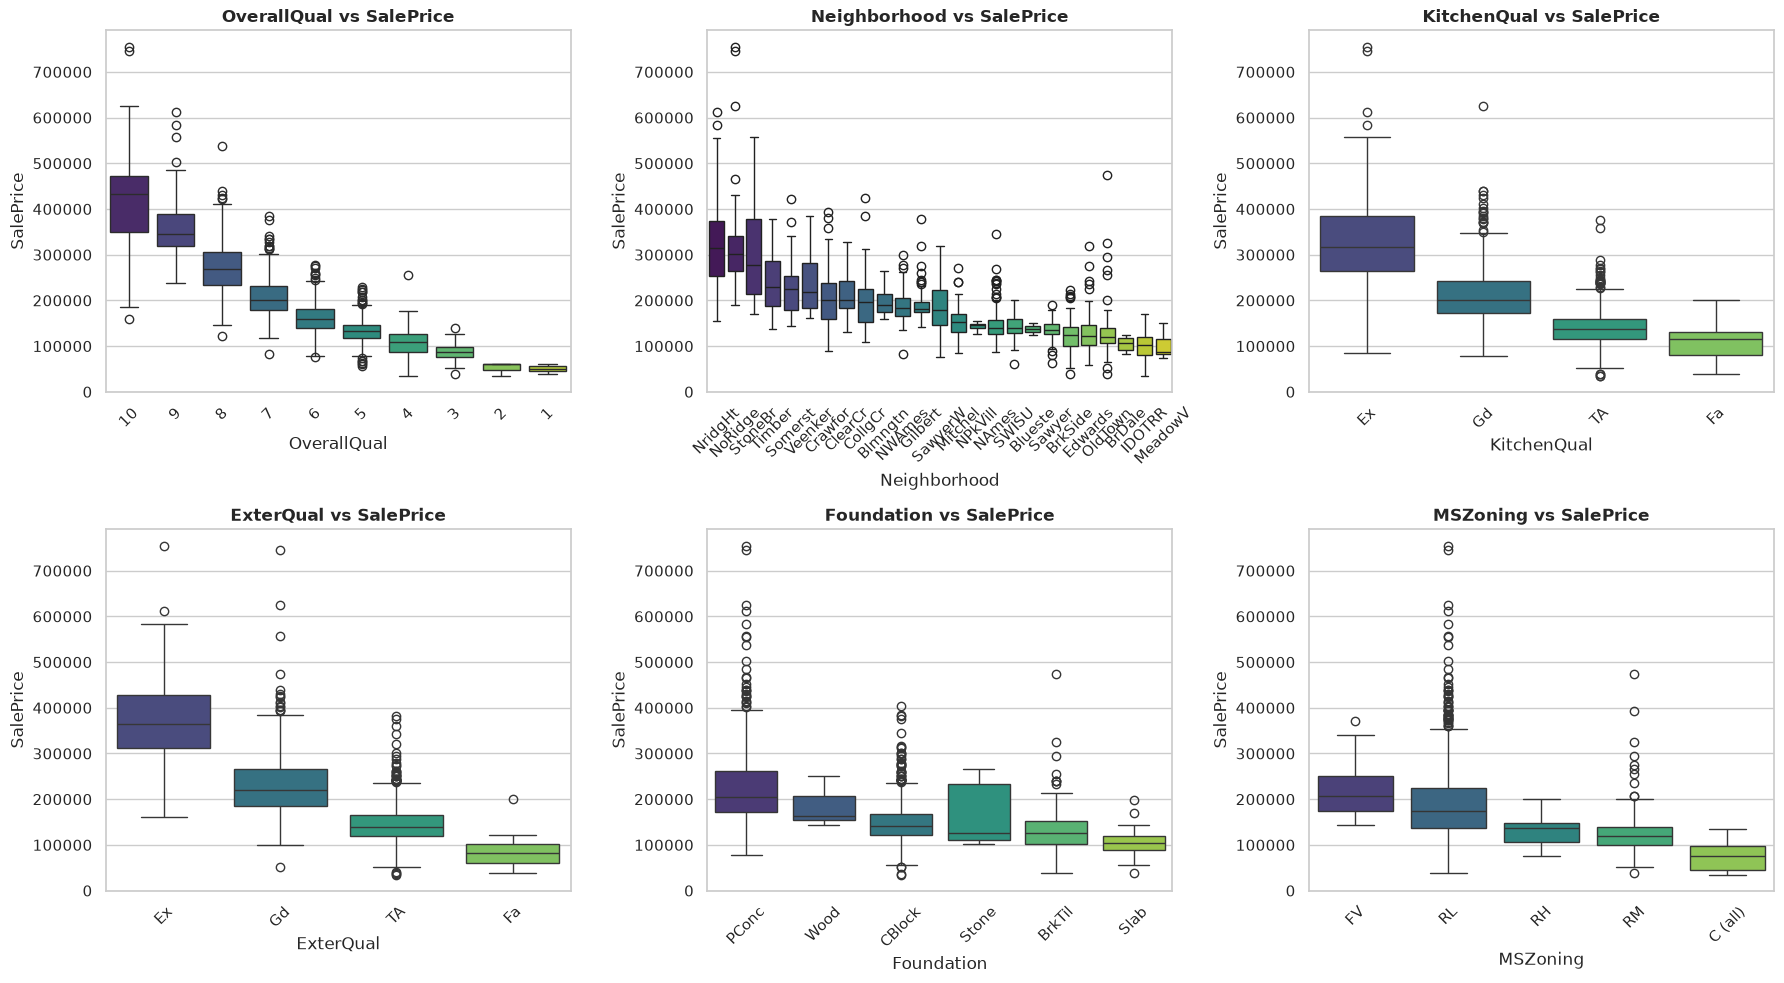

In [10]:
# 10. Box plots: Các feature categorical ảnh hưởng đến giá
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_plot_features = ['OverallQual', 'Neighborhood', 'KitchenQual', 'ExterQual', 'Foundation', 'MSZoning']

for i, feature in enumerate(cat_plot_features):
    order = df.groupby(feature)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feature, y='SalePrice', ax=axes[i], order=order, palette='viridis')
    axes[i].set_title(f'{feature} vs SalePrice', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

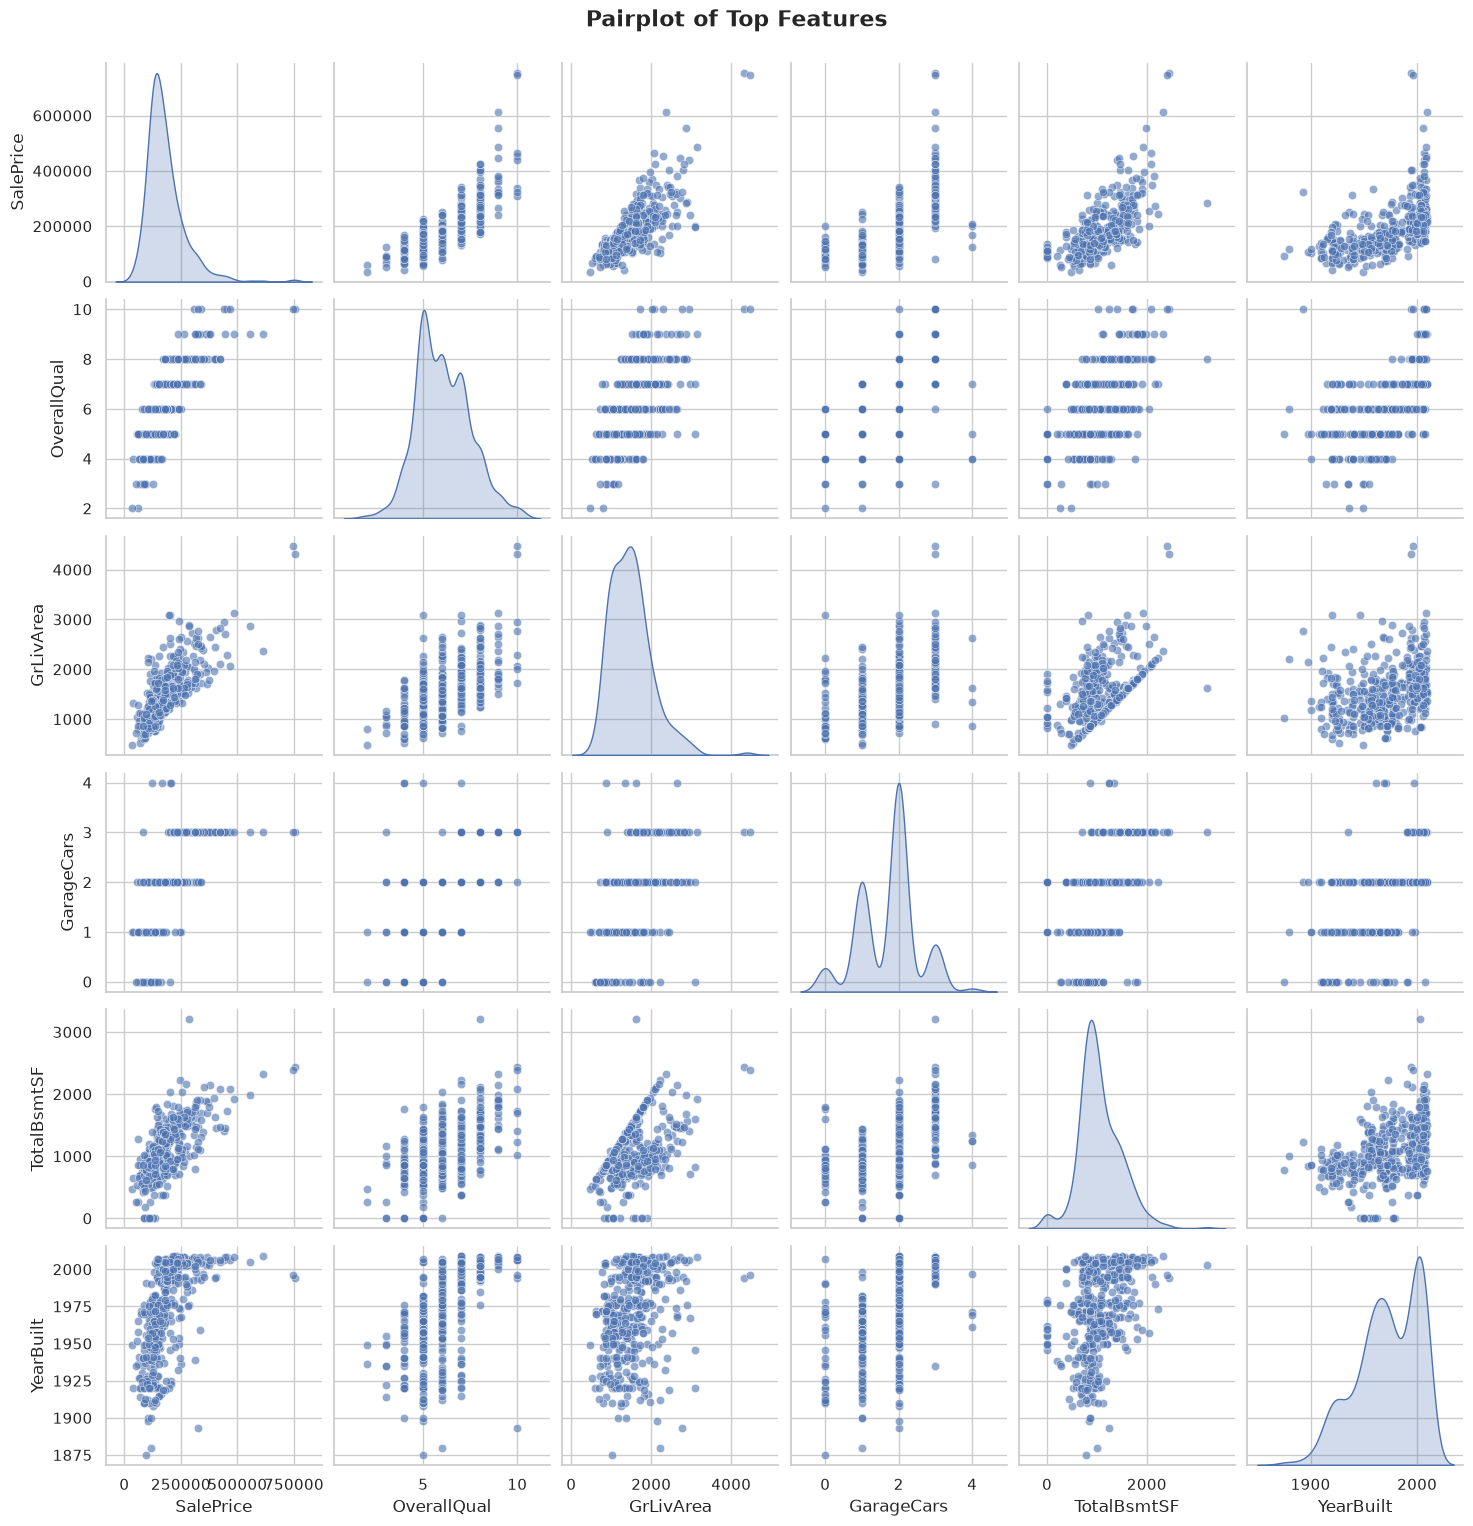

In [11]:
# 11. Pairplot của top features (lấy mẫu để dễ nhìn)
top_features_for_pairplot = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']

# Lấy mẫu 500 dòng cho pairplot nếu data lớn
sample_df = df[top_features_for_pairplot].sample(min(500, len(df)), random_state=42)

sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Top Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()

Số lượng outliers (IQR): 61 / 1460 (4.2%)
Lower bound: $3938
Upper bound: $340038


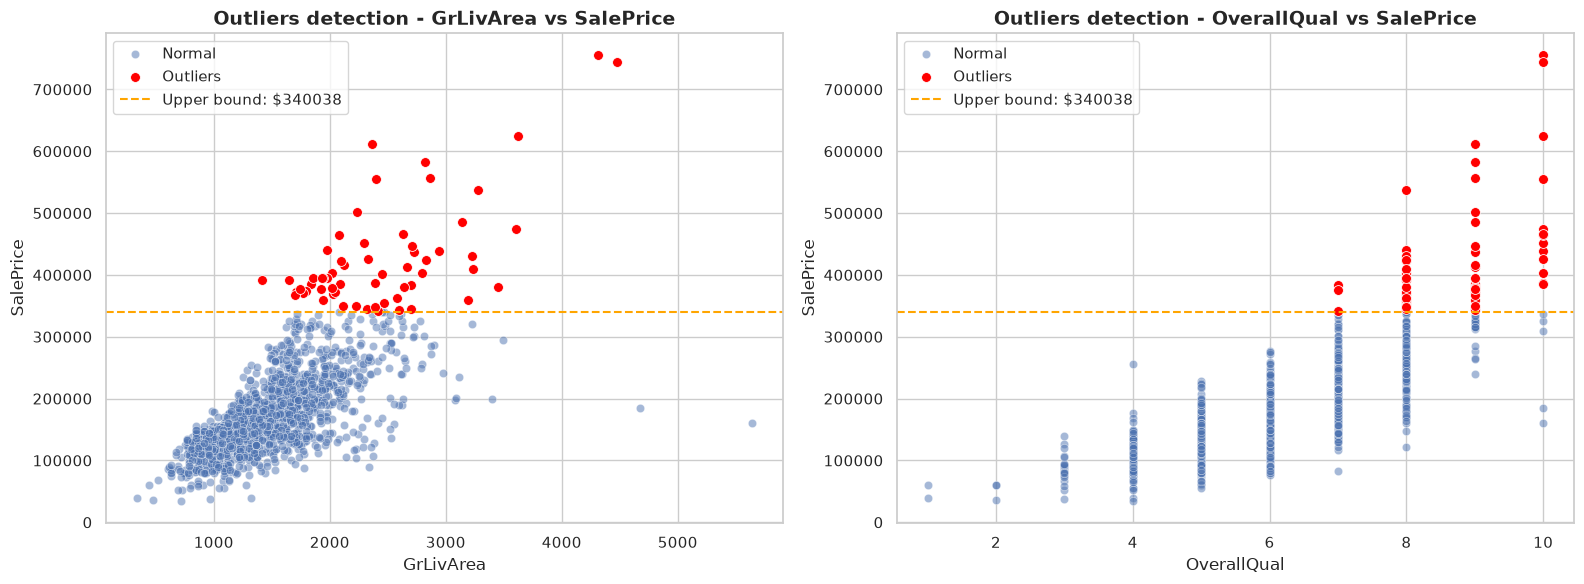

In [12]:
# 12. Phát hiện outliers bằng IQR
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)]
print(f'Số lượng outliers (IQR): {len(outliers)} / {len(df)} ({len(outliers)/len(df)*100:.1f}%)')
print(f'Lower bound: ${lower_bound:.0f}')
print(f'Upper bound: ${upper_bound:.0f}')

# Trực quan hóa outliers trên scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.5, ax=axes[0], label='Normal')
sns.scatterplot(data=outliers, x='GrLivArea', y='SalePrice', color='red', s=50, ax=axes[0], label='Outliers')
axes[0].axhline(upper_bound, color='orange', linestyle='--', label=f'Upper bound: ${upper_bound:.0f}')
axes[0].set_title('Outliers detection - GrLivArea vs SalePrice', fontsize=14, fontweight='bold')
axes[0].legend()

sns.scatterplot(data=df, x='OverallQual', y='SalePrice', alpha=0.5, ax=axes[1], label='Normal')
sns.scatterplot(data=outliers, x='OverallQual', y='SalePrice', color='red', s=50, ax=axes[1], label='Outliers')
axes[1].axhline(upper_bound, color='orange', linestyle='--', label=f'Upper bound: ${upper_bound:.0f}')
axes[1].set_title('Outliers detection - OverallQual vs SalePrice', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 🔬 Feature Selection - Phân tích & Lựa chọn Features

Sử dụng **3 phương pháp** để chọn features:
1. **Correlation Analysis** - Tương quan tuyến tính với SalePrice
2. **Mutual Information** - Phụ thuộc phi tuyến giữa feature và target
3. **RFE (Recursive Feature Elimination)** - Loại bỏ đệ quy dựa trên model

Kết hợp cả 3 phương pháp + domain knowledge để chọn features cuối cùng.

Tổng số feature candidates: 75


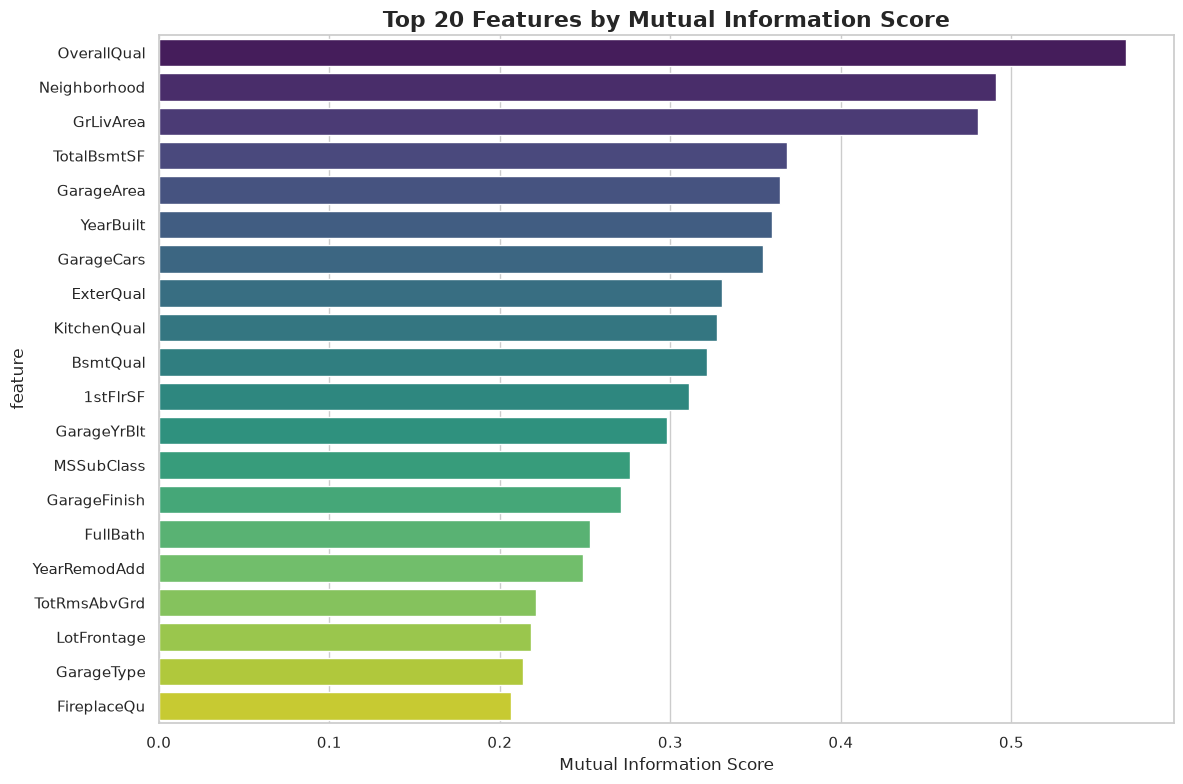


Top 10 features theo Mutual Information (quan hệ phi tuyến):


,feature,mi_score
0,OverallQual,0.566972
38,Neighborhood,0.491033
4,GrLivArea,0.480302
5,TotalBsmtSF,0.368623
9,GarageArea,0.364438
2,YearBuilt,0.359671
8,GarageCars,0.354371
48,ExterQual,0.330325
60,KitchenQual,0.327139
51,BsmtQual,0.321408


In [13]:
# 13. Mutual Information - Phát hiện quan hệ phi tuyến

# Chuẩn bị dữ liệu: mã hóa tạm categorical để tính MI
df_mi = df.copy()

# Chọn các cột numeric + ordinal categorical
mi_candidates = [
    'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 
    'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
    'GarageCars', 'GarageArea', 'GarageYrBlt',
    'LotArea', 'LotFrontage', 'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch',
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
    'Fireplaces', 'MoSold', 'YrSold', 'MiscVal', 'PoolArea',
    'MSSubClass', 'LotShape', 'LandContour', 'LotConfig',
    'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
    'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'ExterQual', 'ExterCond', 'Foundation',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
    'KitchenQual', 'Functional',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
    'SaleType', 'SaleCondition', 'Street', 'Alley'
]

# Loại các cột không tồn tại
mi_candidates = [c for c in mi_candidates if c in df_mi.columns]
print(f'Tổng số feature candidates: {len(mi_candidates)}')

# Mã hóa categorical thành số bằng OrdinalEncoder
cat_cols_mi = df_mi[mi_candidates].select_dtypes(include=['object']).columns
for col in cat_cols_mi:
    df_mi[col] = pd.factorize(df_mi[col])[0]

# Điền missing
for col in mi_candidates:
    df_mi[col] = df_mi[col].fillna(df_mi[col].median() if df_mi[col].dtype in ['int64','float64'] else df_mi[col].mode()[0])

# Tính Mutual Information
mi_scores = mutual_info_regression(df_mi[mi_candidates], df_mi['SalePrice'], random_state=42)
mi_df = pd.DataFrame({'feature': mi_candidates, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

# Vẽ biểu đồ Top 20 theo MI
plt.figure(figsize=(12, 8))
top_mi = mi_df.head(20)
sns.barplot(data=top_mi, y='feature', x='mi_score', palette='viridis')
plt.title('Top 20 Features by Mutual Information Score', fontsize=16, fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

print('\nTop 10 features theo Mutual Information (quan hệ phi tuyến):')
mi_df.head(10)

In [14]:
# 14. RFE (Recursive Feature Elimination) - Dùng Linear Regression để loại bỏ dần

# Chỉ dùng numeric features cho RFE (tránh one-hot phức tạp)
rfe_candidates = [
    'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
    'GrLivArea', 'TotalBsmtSF', '1stFlrSF',
    'GarageCars', 'GarageArea', 'LotArea',
    'FullBath', 'HalfBath', 'BsmtFullBath',
    'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
    'BsmtFinSF1', 'BsmtUnfSF', 'MasVnrArea',
    'WoodDeckSF', 'OpenPorchSF', 'LotFrontage', 'MoSold'
]
rfe_candidates = [c for c in rfe_candidates if c in df.columns]

# Điền missing
df_rfe = df[rfe_candidates].copy()
for col in df_rfe.columns:
    df_rfe[col] = df_rfe[col].fillna(df_rfe[col].median())

# RFE với Linear Regression
estimator = LinearRegression()
selector = RFE(estimator, n_features_to_select=10, step=1)
selector.fit(df_rfe, df['SalePrice'])

# Kết quả
rfe_results = pd.DataFrame({
    'feature': rfe_candidates,
    'selected': selector.support_,
    'rank': selector.ranking_
}).sort_values('rank')

print('🏆 RFE - Top 10 features được chọn:')
for i, row in rfe_results[rfe_results['selected']].iterrows():
    print(f'  ✅ {row["feature"]}')

print('\n📊 Xếp hạng đầy đủ:')
rfe_results

🏆 RFE - Top 10 features được chọn:
  ✅ OverallQual
  ✅ OverallCond
  ✅ YearBuilt
  ✅ GarageCars
  ✅ BsmtFullBath
  ✅ BedroomAbvGr
  ✅ FullBath
  ✅ HalfBath
  ✅ TotRmsAbvGrd
  ✅ Fireplaces

📊 Xếp hạng đầy đủ:


,feature,selected,rank
0,OverallQual,True,1
1,OverallCond,True,1
2,YearBuilt,True,1
7,GarageCars,True,1
12,BsmtFullBath,True,1
13,BedroomAbvGr,True,1
10,FullBath,True,1
11,HalfBath,True,1
14,TotRmsAbvGrd,True,1
15,Fireplaces,True,1


In [15]:
# 15. Feature Selection - Giải thích chi tiết từng nhóm features

# ============================================
# NHÓM 1: CHẤT LƯỢNG & ĐẶC ĐIỂM TỔNG THỂ
# ============================================
num_features = [
    'OverallQual',    # (Corr: 0.79) ⭐ QUAN TRỌNG NHẤT - đánh giá tổng thể chất lượng (1-10)
    'OverallCond',    # Tình trạng tổng thể (bổ sung cho OverallQual)
    'YearBuilt',      # (Corr: 0.52) Nhà mới hơn thường đắt hơn, ảnh hưởng đến khấu hao
    'YearRemodAdd',   # Năm cải tạo - nhà được cải tạo gần đây thường có giá cao hơn
    'MoSold',         # Tháng bán - giá nhà có thể thay đổi theo mùa trong năm
]

# ============================================
# NHÓM 2: DIỆN TÍCH (Square Footage) - Tương quan rất cao với giá
# ============================================
area_features = [
    'GrLivArea',      # (Corr: 0.71) ⭐ Tổng diện tích sinh hoạt chính - feature số mạnh thứ 2
    'TotalBsmtSF',    # (Corr: 0.61) Diện tích tầng hầm
    '1stFlrSF',       # (Corr: 0.61) Diện tích tầng 1
    'LotArea',        # (Corr: 0.26) Diện tích đất - quan trọng cho bất động sản
    'LotFrontage',    # Mặt tiền - ảnh hưởng đến giá trị đất
    'MasVnrArea',     # (Corr: 0.48) Diện tích ốp đá/gạch mặt tiền - thể hiện sự sang trọng
    'BsmtFinSF1',     # Diện tích tầng hầm đã hoàn thiện - có giá trị hơn chưa hoàn thiện
    'BsmtUnfSF',      # Diện tích tầng hầm chưa hoàn thiện (bổ sung cho TotalBsmtSF)
]

# ============================================
# NHÓM 3: GARA - Phần lớn nhà ở Mỹ đều có gara
# ============================================
garage_features = [
    'GarageCars',     # (Corr: 0.64) ⭐ Số xe để được - feature quan trọng
    'GarageArea',     # (Corr: 0.62) Diện tích gara (tương quan cao với GarageCars, nên có thể chọn 1)
]

# ============================================
# NHÓM 4: PHÒNG ỐC & TIỆN NGHI
# ============================================
room_features = [
    'FullBath',       # (Corr: 0.56) ⭐ Số phòng tắm đầy đủ
    'HalfBath',       # Phòng tắm 1/2
    'BsmtFullBath',   # Phòng tắm tầng hầm
    'BsmtHalfBath',   # Phòng tắm 1/2 tầng hầm
    'BedroomAbvGr',   # Số phòng ngủ
    'TotRmsAbvGrd',   # Tổng số phòng (trừ phòng tắm)
    'Fireplaces',     # (Corr: 0.47) Lò sưởi - feature được ưa chuộng ở Mỹ
]

# ============================================
# NHÓM 5: NGOẠI THẤT & TIỆN ÍCH NGOÀI TRỜI
# ============================================
outdoor_features = [
    'WoodDeckSF',     # Diện tích sàn gỗ ngoài trời
    'OpenPorchSF',    # Diện tích hiên mở
]

# Hợp nhất tất cả numeric features
num_features = num_features + area_features + garage_features + room_features + outdoor_features
print(f'✅ Tổng số numeric features: {len(num_features)}')

# ============================================
# NHÓM 6: CATEGORICAL FEATURES
# ============================================
cat_features = [
    'Neighborhood',   # ⭐ Khu vực - ảnh hưởng RẤT LỚN đến giá (trung tâm > ngoại ô)
    'KitchenQual',    # ⭐ Chất lượng bếp - kitchen là trái tim của ngôi nhà
    'ExterQual',      # Chất lượng ngoại thất - ấn tượng đầu tiên khi nhìn vào nhà
    'BsmtQual',       # Chất lượng tầng hầm - tầng hầm tốt = thêm không gian sống
    'Foundation',     # Loại móng - PConc (bê tông) thường đắt hơn BrkTil (gạch)
    'MSZoning',       # Phân vùng quy hoạch - ảnh hưởng đến mật độ xây dựng
    'GarageFinish',   # Mức độ hoàn thiện gara - RFn (hoàn thiện) > Unf (chưa hoàn thiện)
    'BsmtFinType1',   # Loại hoàn thiện tầng hầm - GLQ (tốt) > ALQ (trung bình) > Unf
    'FireplaceQu',    # Chất lượng lò sưởi - bổ sung cho Fireplaces
]

print(f'✅ Tổng số categorical features: {len(cat_features)}')
print(f'📊 Tổng cộng: {len(num_features)} numeric + {len(cat_features)} categorical = {len(num_features) + len(cat_features)} features')

✅ Tổng số numeric features: 24
✅ Tổng số categorical features: 9
📊 Tổng cộng: 24 numeric + 9 categorical = 33 features


### 🔍 Tổng kết Feature Selection

| Phương pháp | Mô tả |
|---|---|
| **Correlation (EDA)** | Chọn features có tương quan tuyến tính cao với SalePrice |
| **Mutual Information** | Phát hiện quan hệ phi tuyến (ví dụ: OverallQual có MI cao hơn Corr) |
| **RFE** | Linear Regression tự động loại bỏ features yếu nhất |
| **Domain Knowledge** | Hiểu biết về thị trường BĐS: Neighborhood, KitchenQual, Foundation... |

**Features bị loại:** `Id`, `PoolArea`/`PoolQC`, `Alley`, `Fence`, `MiscFeature`, `Street`, `Utilities`, `LandSlope`, `LowQualFinSF`, `3SsnPorch`

In [16]:
# 16. Feature Engineering: tạo thêm feature mới

df_processed = df.copy()

# Tổng diện tích
df_processed['TotalSF'] = df_processed['TotalBsmtSF'] + df_processed['1stFlrSF'] + df_processed['2ndFlrSF']

# Tổng số phòng tắm (dạng weighted)
df_processed['TotalBath'] = (
    df_processed['FullBath'] 
    + 0.5 * df_processed['HalfBath'] 
    + df_processed['BsmtFullBath'] 
    + 0.5 * df_processed['BsmtHalfBath']
)

# Tuổi nhà khi bán
df_processed['HouseAge'] = df_processed['YrSold'] - df_processed['YearBuilt']

# Tuổi cải tạo
df_processed['RemodAge'] = df_processed['YrSold'] - df_processed['YearRemodAdd']

# Có cải tạo không?
df_processed['HasRemod'] = (df_processed['YearRemodAdd'] != df_processed['YearBuilt']).astype(int)

# Tương tác: Chất lượng x Diện tích
df_processed['OverallQual_GrLiv'] = df_processed['OverallQual'] * df_processed['GrLivArea']

# Trung bình diện tích mỗi phòng
df_processed['AvgRoomSize'] = df_processed['GrLivArea'] / df_processed['TotRmsAbvGrd'].replace(0, 1)

print('✅ Feature Engineering hoàn tất!')
print(f'Feature mới: TotalSF, TotalBath, HouseAge, RemodAge, HasRemod, OverallQual_GrLiv, AvgRoomSize')

✅ Feature Engineering hoàn tất!
Feature mới: TotalSF, TotalBath, HouseAge, RemodAge, HasRemod, OverallQual_GrLiv, AvgRoomSize


In [17]:
# 17. Xử lý missing values

# Thêm feature engineered vào danh sách
engineered_features = ['TotalSF', 'TotalBath', 'HouseAge', 'RemodAge', 'HasRemod', 'OverallQual_GrLiv', 'AvgRoomSize']
all_num_features = num_features + engineered_features

# Xử lý missing cho numeric: điền bằng median
for col in all_num_features:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# Xử lý missing cho categorical: điền bằng 'None'
for col in cat_features:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].fillna('None')

print('✅ Missing values đã được xử lý!')

# Kiểm tra lại
remaining_missing = df_processed[all_num_features + cat_features + ['SalePrice']].isnull().sum()
print(f'\nMissing còn lại: {remaining_missing[remaining_missing > 0].sum()}')

✅ Missing values đã được xử lý!

Missing còn lại: 0


In [18]:
# 18. Log-transform SalePrice (chuẩn bị cho model)
y = np.log1p(df_processed['SalePrice'])

# Chọn feature matrix
X = df_processed[all_num_features + cat_features]

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\ny (log SalePrice) - min: {y.min():.2f}, max: {y.max():.2f}, mean: {y.mean():.2f}')

X shape: (1460, 40)
y shape: (1460,)

y (log SalePrice) - min: 10.46, max: 13.53, mean: 12.02


In [19]:
# 19. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape}')
print(f'Test size: {X_test.shape}')

Train size: (1168, 40)
Test size: (292, 40)


In [20]:
# 20. Tạo preprocessing pipeline

# Transformer cho numeric: impute median + scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformer cho categorical: impute 'None' + one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Kết hợp
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, all_num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

print('✅ Preprocessing pipeline đã được tạo!')
print(f'⏳ Cần fit pipeline trước để xem số features cuối cùng')

✅ Preprocessing pipeline đã được tạo!
⏳ Cần fit pipeline trước để xem số features cuối cùng


## 🤖 Model Training với sklearn

In [21]:
# 21. Định nghĩa hàm đánh giá

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name='Model'):
    """
    Huấn luyện và đánh giá model
    Trả về: y_pred (giá trị log) và metrics dict
    """
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics (trên log scale)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # CV score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    print(f'\n{"="*50}')
    print(f'📊 {model_name}')
    print(f'{"="*50}')
    print(f'Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}')
    print(f'Train MAE : {train_mae:.4f} | Test MAE : {test_mae:.4f}')
    print(f'Train R²  : {train_r2:.4f} | Test R²  : {test_r2:.4f}')
    print(f'CV R²     : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')
    
    # Chuyển về giá gốc để đánh giá thực tế
    y_train_orig = np.expm1(y_train)
    y_train_pred_orig = np.expm1(y_train_pred)
    y_test_orig = np.expm1(y_test)
    y_test_pred_orig = np.expm1(y_test_pred)
    
    print(f'\n💰 Giá gốc (USD):')
    print(f'Test MAE  : ${mean_absolute_error(y_test_orig, y_test_pred_orig):.0f}')
    print(f'Test RMSE : ${np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig)):.0f}')
    print(f'Test R²   : {r2_score(y_test_orig, y_test_pred_orig):.4f}')
    print(f'{"="*50}')
    
    metrics = {
        'model': model_name,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'test_mae_orig': mean_absolute_error(y_test_orig, y_test_pred_orig),
        'test_rmse_orig': np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig)),
        'test_r2_orig': r2_score(y_test_orig, y_test_pred_orig),
    }
    
    return metrics, y_test_pred

In [22]:
# 22. Huấn luyện các model

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0),
    'Lasso Regression': Lasso(alpha=0.001),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
}

results = []
predictions = {}

for name, model in models.items():
    # Tạo pipeline: preprocessing + model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    metrics, y_pred = evaluate_model(pipeline, X_train, y_train, X_test, y_test, name)
    results.append(metrics)
    predictions[name] = y_pred


📊 Linear Regression
Train RMSE: 0.1258 | Test RMSE: 0.1277
Train MAE : 0.0880 | Test MAE : 0.0909
Train R²  : 0.8962 | Test R²  : 0.9126
CV R²     : 0.8578 (+/- 0.0668)

💰 Giá gốc (USD):
Test MAE  : $16994
Test RMSE : $29831
Test R²   : 0.8840



📊 Ridge Regression
Train RMSE: 0.1277 | Test RMSE: 0.1336
Train MAE : 0.0880 | Test MAE : 0.0929
Train R²  : 0.8930 | Test R²  : 0.9044
CV R²     : 0.8602 (+/- 0.0870)

💰 Giá gốc (USD):
Test MAE  : $16978
Test RMSE : $29501
Test R²   : 0.8865



📊 Lasso Regression
Train RMSE: 0.1314 | Test RMSE: 0.1387
Train MAE : 0.0895 | Test MAE : 0.0973
Train R²  : 0.8867 | Test R²  : 0.8969
CV R²     : 0.8563 (+/- 0.0969)

💰 Giá gốc (USD):
Test MAE  : $17462
Test RMSE : $29716
Test R²   : 0.8849



📊 Decision Tree
Train RMSE: 0.0468 | Test RMSE: 0.2074
Train MAE : 0.0296 | Test MAE : 0.1425
Train R²  : 0.9856 | Test R²  : 0.7696
CV R²     : 0.7279 (+/- 0.0474)

💰 Giá gốc (USD):
Test MAE  : $23776
Test RMSE : $37276
Test R²   : 0.8188



📊 Random Forest
Train RMSE: 0.0521 | Test RMSE: 0.1475
Train MAE : 0.0352 | Test MAE : 0.0968
Train R²  : 0.9822 | Test R²  : 0.8834
CV R²     : 0.8682 (+/- 0.0575)

💰 Giá gốc (USD):
Test MAE  : $17195
Test RMSE : $30284
Test R²   : 0.8804



📊 Gradient Boosting
Train RMSE: 0.0213 | Test RMSE: 0.1470
Train MAE : 0.0166 | Test MAE : 0.0958
Train R²  : 0.9970 | Test R²  : 0.8842
CV R²     : 0.8749 (+/- 0.0494)

💰 Giá gốc (USD):
Test MAE  : $16882
Test RMSE : $29552
Test R²   : 0.8861


In [23]:
# 23. So sánh kết quả các model

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_r2_orig', ascending=False)

# Chỉ hiển thị các cột quan trọng
display_cols = ['model', 'test_r2', 'cv_r2_mean', 'test_rmse_orig', 'test_mae_orig', 'test_r2_orig']
print('📋 Bảng so sánh các Model:')
results_df[display_cols].round(4)

📋 Bảng so sánh các Model:


,model,test_r2,cv_r2_mean,test_rmse_orig,test_mae_orig,test_r2_orig
1,Ridge Regression,0.9044,0.8602,29501.0810,16978.1158,0.8865
5,Gradient Boosting,0.8842,0.8749,29551.6623,16881.8546,0.8861
2,Lasso Regression,0.8969,0.8563,29715.8480,17461.9855,0.8849
0,Linear Regression,0.9126,0.8578,29830.9766,16994.3090,0.8840
4,Random Forest,0.8834,0.8682,30284.2141,17194.7693,0.8804
3,Decision Tree,0.7696,0.7279,37276.2167,23776.0571,0.8188


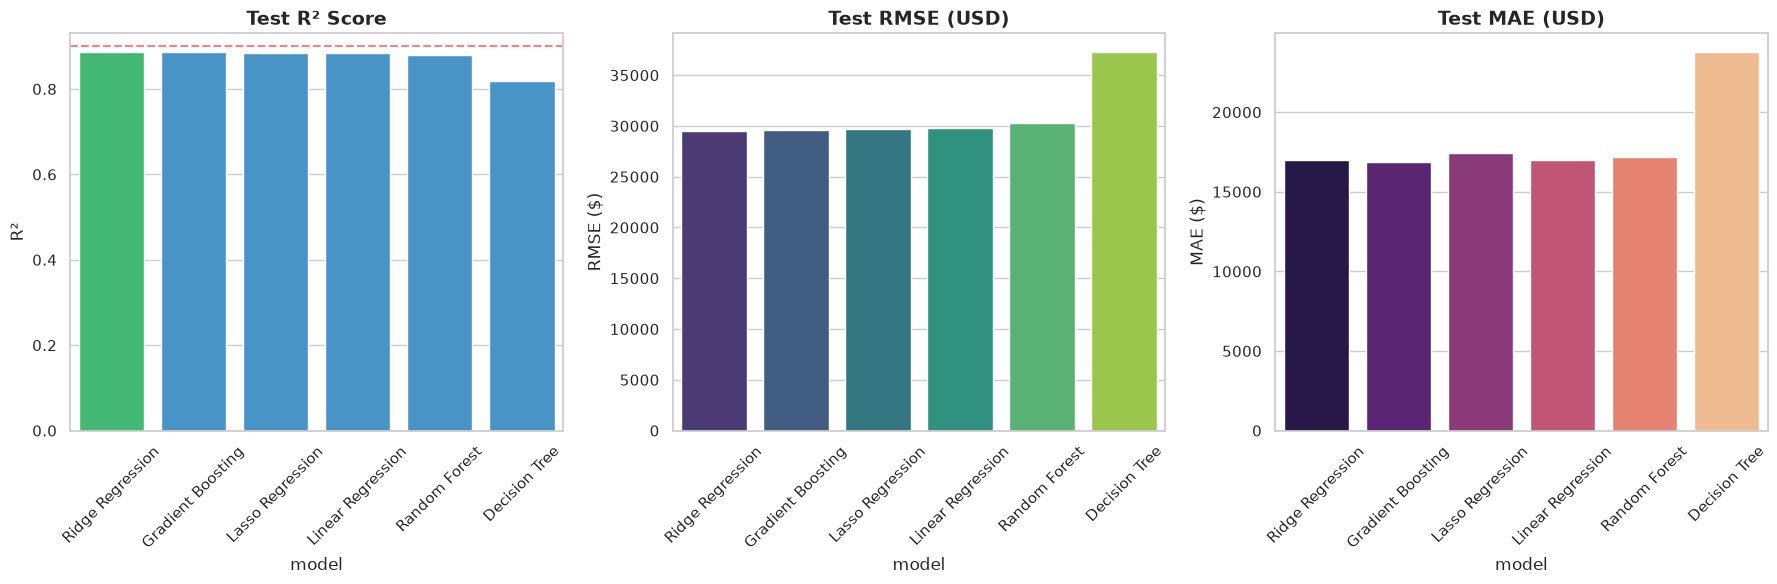

In [24]:
# 24. Trực quan hóa so sánh các model

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# R² comparison
best_r2 = results_df['test_r2_orig'].max()
colors = ['#2ecc71' if r == best_r2 else '#3498db' for r in results_df['test_r2_orig']]
sns.barplot(data=results_df, x='model', y='test_r2_orig', ax=axes[0], palette=colors)
axes[0].set_title('Test R² Score', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(0.9, color='red', linestyle='--', alpha=0.5)

# RMSE comparison
sns.barplot(data=results_df, x='model', y='test_rmse_orig', ax=axes[1], palette='viridis')
axes[1].set_title('Test RMSE (USD)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RMSE ($)')
axes[1].tick_params(axis='x', rotation=45)

# MAE comparison
sns.barplot(data=results_df, x='model', y='test_mae_orig', ax=axes[2], palette='magma')
axes[2].set_title('Test MAE (USD)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('MAE ($)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

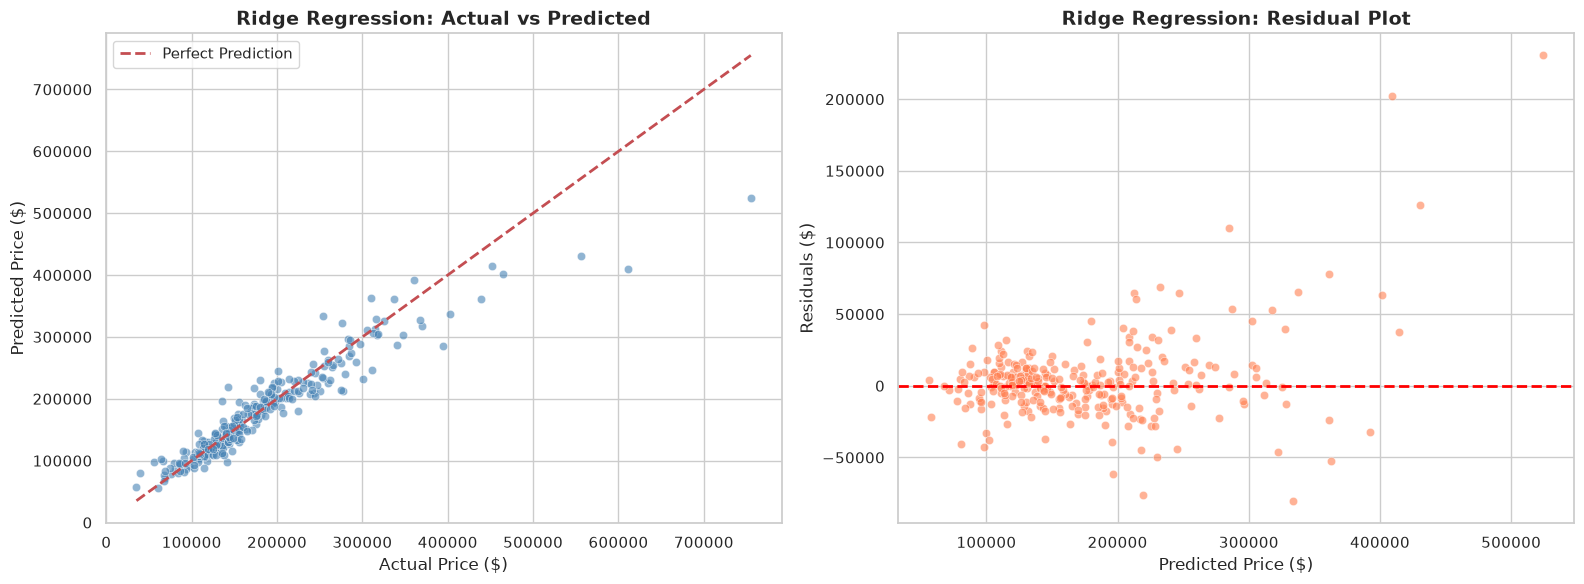

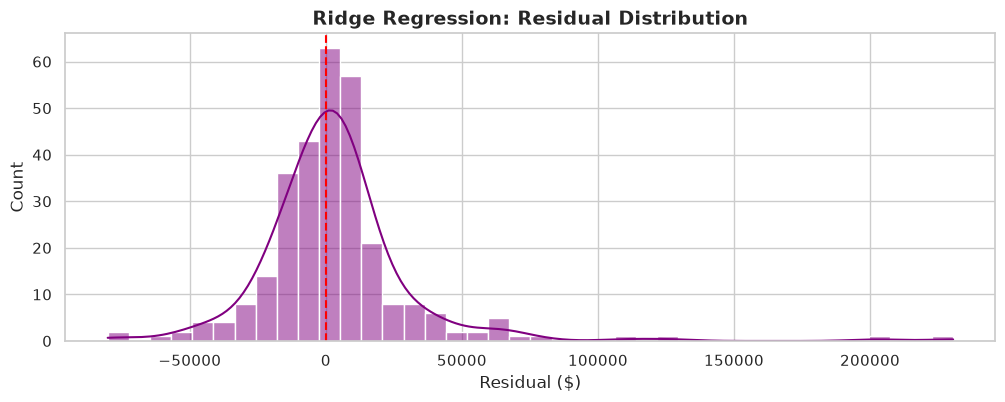

Residual mean: 3533
Residual std:  29339


In [25]:
# 25. Actual vs Predicted cho model tốt nhất

best_model_name = results_df.iloc[0]['model']
y_test_pred_best = predictions[best_model_name]
y_test_orig = np.expm1(y_test)
y_test_pred_orig = np.expm1(y_test_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Actual vs Predicted
sns.scatterplot(x=y_test_orig, y=y_test_pred_orig, alpha=0.6, ax=axes[0], color='steelblue')
min_val = min(y_test_orig.min(), y_test_pred_orig.min())
max_val = max(y_test_orig.max(), y_test_pred_orig.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].legend()

# Residual plot
residuals = y_test_orig - y_test_pred_orig
sns.scatterplot(x=y_test_pred_orig, y=residuals, alpha=0.6, ax=axes[1], color='coral')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title(f'{best_model_name}: Residual Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Residual distribution
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(residuals, kde=True, bins=40, color='purple', ax=ax)
ax.axvline(0, color='red', linestyle='--')
ax.set_title(f'{best_model_name}: Residual Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Residual ($)')
plt.show()

print(f'Residual mean: {residuals.mean():.0f}')
print(f'Residual std:  {residuals.std():.0f}')

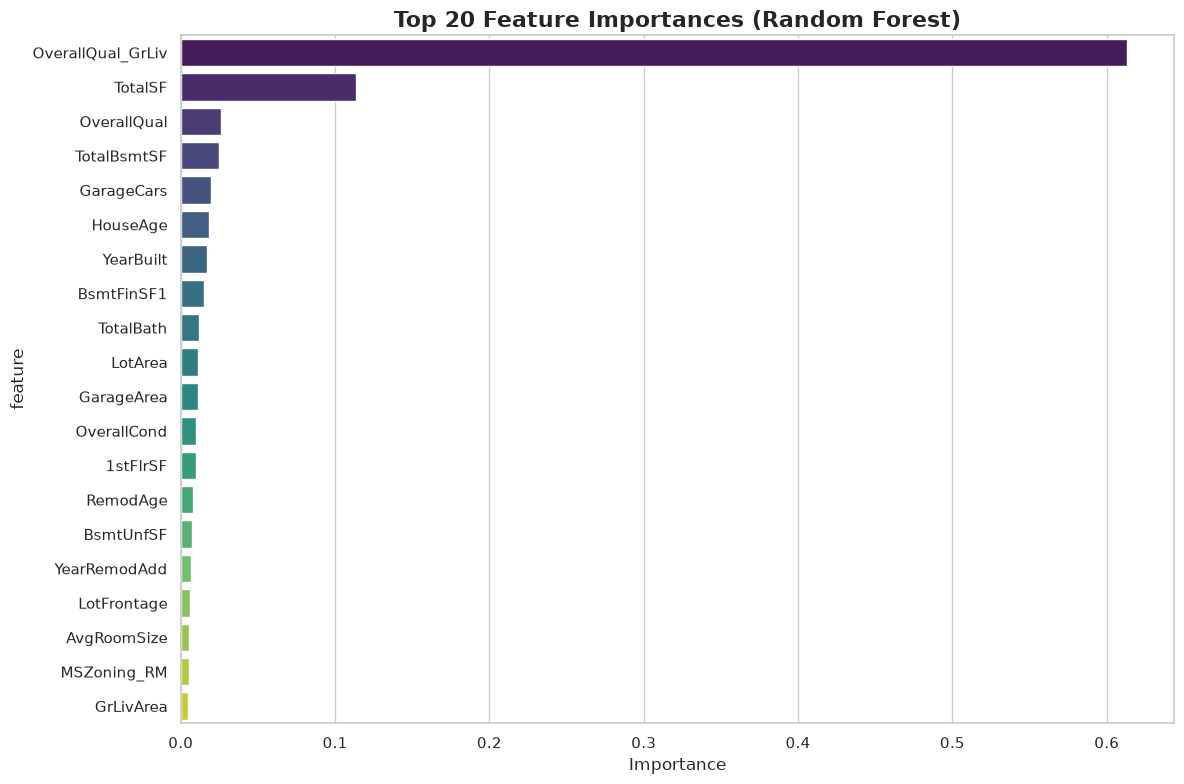

Top 10 features quan trọng nhất:


,feature,importance
29,OverallQual_GrLiv,0.612919
24,TotalSF,0.113691
0,OverallQual,0.026289
6,TotalBsmtSF,0.024930
13,GarageCars,0.019342
26,HouseAge,0.018085
2,YearBuilt,0.016789
11,BsmtFinSF1,0.015171
25,TotalBath,0.011774
8,LotArea,0.011445


In [26]:
# 26. Feature Importance cho Random Forest

# Huấn luyện lại pipeline với RF
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)

# Lấy feature names sau one-hot encoding
feature_names = (
    all_num_features +
    list(rf_pipeline.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(cat_features))
)

# Feature importances
importances = rf_pipeline.named_steps['model'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Top 20 features
plt.figure(figsize=(12, 8))
top_20 = feature_importance_df.head(20)
sns.barplot(data=top_20, y='feature', x='importance', palette='viridis')
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 features quan trọng nhất:')
feature_importance_df.head(10)

In [27]:
# 27. Tuning Gradient Boosting

# Chỉ tuning với sample nhỏ để tránh lâu
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=0.3, random_state=42
)

print('Bắt đầu GridSearchCV cho Gradient Boosting...')
print(f'(Training với {len(X_train_sample)} samples)')

# Grid search
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.2],
}

grid_search = GridSearchCV(
    gb_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sample, y_train_sample)

print(f'\n✅ Best parameters: {grid_search.best_params_}')
print(f'Best CV score: {grid_search.best_score_:.4f}')

Bắt đầu GridSearchCV cho Gradient Boosting...
(Training với 350 samples)
Fitting 3 folds for each of 18 candidates, totalling 54 fits



✅ Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV score: 0.8643


In [28]:
# 28. Đánh giá model tuned Gradient Boosting trên full test set

best_params = grid_search.best_params_

gb_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=best_params['model__n_estimators'],
        max_depth=best_params['model__max_depth'],
        learning_rate=best_params['model__learning_rate'],
        random_state=42
    ))
])

metrics_tuned, y_pred_tuned = evaluate_model(
    gb_tuned, X_train, y_train, X_test, y_test,
    f'Gradient Boosting Tuned {best_params}'
)


📊 Gradient Boosting Tuned {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Train RMSE: 0.0796 | Test RMSE: 0.1400
Train MAE : 0.0577 | Test MAE : 0.0946
Train R²  : 0.9585 | Test R²  : 0.8949
CV R²     : 0.8873 (+/- 0.0343)

💰 Giá gốc (USD):
Test MAE  : $17171
Test RMSE : $29385
Test R²   : 0.8874


In [29]:
# 29. Tổng kết kết quả cuối cùng

print('\n' + '='*60)
print('🏆 KẾT QUẢ CUỐI CÙNG')
print('='*60)

# Tìm model tốt nhất từ danh sách đã train (không tính tuned)
best_overall = results_df.iloc[0]
print(f'\n📌 Model tốt nhất (không tuning): {best_overall["model"]}')
print(f'   Test R² : {best_overall["test_r2_orig"]:.4f}')
print(f'   Test MAE: ${best_overall["test_mae_orig"]:.0f}')
print(f'   Test RMSE: ${best_overall["test_rmse_orig"]:.0f}')

print(f'\n📌 Sau khi tuning Gradient Boosting:')
print(f'   Test R² : {metrics_tuned["test_r2_orig"]:.4f}')
print(f'   Test MAE: ${metrics_tuned["test_mae_orig"]:.0f}')
print(f'   Test RMSE: ${metrics_tuned["test_rmse_orig"]:.0f}')
print(f'\n✅ Pipeline hoàn tất!')


🏆 KẾT QUẢ CUỐI CÙNG

📌 Model tốt nhất (không tuning): Ridge Regression
   Test R² : 0.8865
   Test MAE: $16978
   Test RMSE: $29501

📌 Sau khi tuning Gradient Boosting:
   Test R² : 0.8874
   Test MAE: $17171
   Test RMSE: $29385

✅ Pipeline hoàn tất!
